# Intrusion Detection System — Hierarchical (Two-Stage) Classifier
### Dataset: CICIDS-2017  ·  Runs on **Kaggle** (GPU for XGBoost)

## The idea

Instead of one flat 7-class model that has to separate BENIGN (1.7 M rows) from six attack
families simultaneously, we split the problem into a **cascade**:

```
                       ┌─────────────────────────┐
   network flow  ───►  │  STAGE 1 : gatekeeper   │   BENIGN vs ATTACK (binary MLP)
                       └─────────────────────────┘
                            │                │
                  predicted BENIGN     predicted ATTACK
                            │                │
                            ▼                ▼
                        output:        ┌─────────────────────────┐
                        BENIGN         │  STAGE 2 : specialist   │  which of 6 attack
                                       └─────────────────────────┘  families? (MLP / XGB)
```

**Why it might help.** In the flat model, Bot/Infiltration (1,591 rows) faces BENIGN at
**1080:1**. Remove BENIGN and the Stage-2 specialist sees Bot/Infiltration against the
largest *attack* class (DoS, 155k) at only **~97:1** — an order of magnitude milder. The
specialist can spend all its capacity separating attacks instead of mostly learning
"is this BENIGN?", a job Stage 1 already does at 0.997 F1.

**The honest caveat — error propagation.** If Stage 1 calls an attack "BENIGN", Stage 2
never sees it: that error is unrecoverable. So the cascade's true quality is
`Stage1_recall(ATTACK) × Stage2_quality`, **not** Stage 2 in isolation. This notebook
evaluates the **full cascade end-to-end on the real-distribution test set**, so the
comparison against the flat 7-class model is fair.

## What we build
| Stage | Model | Trained on |
|---|---|---|
| 1 — gate | Binary MLP (from scratch) | full training set, BENIGN vs ATTACK |
| 2a — specialist | Multi-class MLP (from scratch) | **attack rows only**, 6 re-indexed classes |
| 2b — specialist | XGBoost (GPU) | **attack rows only**, 6 re-indexed classes |

Then: run gate → specialist end-to-end, and compare the cascade's 7-class macro-F1 against
the flat scratch-MLP (0.8439) and flat XGBoost (0.9722) from notebooks 08 and 09.

## Kaggle setup
Attach the FeatureSelection output dataset (same one used by every modelling notebook).
Enable **GPU** for the XGBoost specialist. Set `IN_DIR` below to the mount path.

## 1. Imports, Config & Report Helpers

In [1]:
import os, json, time, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# full 7-class names (label_multi index -> name)
CLASS_NAMES = ['BENIGN', 'Bot/Infiltration', 'Brute Force', 'DDoS',
               'DoS', 'PortScan', 'Web Attack']
BENIGN_IDX  = 0
# the 6 attack classes, in their original label_multi order (BENIGN removed)
ATTACK_CLASS_IDS   = [1, 2, 3, 4, 5, 6]
ATTACK_CLASS_NAMES = [CLASS_NAMES[i] for i in ATTACK_CLASS_IDS]
N_ATTACK = len(ATTACK_CLASS_IDS)

# ── Kaggle paths ───────────────────────────────────────────────────
IN_DIR      = '/kaggle/input/datasets/hanzlahmunir/fs-output'   # EDIT to your FeatureSelection mount path
OUT_DIR     = '/kaggle/working'
FIGURES_DIR = os.path.join(OUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

_report_lines = []
def _log(t=''):
    _report_lines.append(str(t)); print(t)
def _savefig(name, fig=None):
    p = os.path.join(FIGURES_DIR, name); (fig or plt).savefig(p, dpi=130, bbox_inches='tight'); return p
def write_report():
    p = os.path.join(OUT_DIR, 'Modeling_Hierarchical_Report.txt')
    with open(p, 'w', encoding='utf-8') as f: f.write('\n'.join(_report_lines))
    print(f'\nReport saved -> {p}')

try:
    import subprocess; subprocess.check_output(['nvidia-smi', '-L']); GPU_AVAILABLE = True
except Exception:
    GPU_AVAILABLE = False

_log('=' * 70)
_log('HIERARCHICAL (TWO-STAGE) CLASSIFIER REPORT  —  CICIDS-2017')
_log(f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}')
_log(f'GPU available : {GPU_AVAILABLE}')
_log('=' * 70)
print('\nSetup complete. Reading from', IN_DIR)

HIERARCHICAL (TWO-STAGE) CLASSIFIER REPORT  —  CICIDS-2017
Generated : 2026-05-21 04:47
GPU available : True

Setup complete. Reading from /kaggle/input/datasets/hanzlahmunir/fs-output


## 2. Load Data & Build the Attack-Only Subset
Stage 1 trains on the full data (BENIGN vs ATTACK). Stage 2 trains on **attack rows only**,
with the labels **re-indexed** to 0–5 (so the 6 attack families form a clean 0-based target
for the specialist). We keep a mapping back to the original 7-class indices for the final
end-to-end evaluation.


── SECTION 2 : DATA LOADED ────────────────────────────────
  Features                 : 47
  Full train rows          : 2,059,411
  Attack-only train rows   : 340,702
  Test rows (real dist.)   : 514,853

  Stage-2 (attack-only) class distribution + imbalance:
    0 = Bot/Infiltration      1,591
    1 = Brute Force           7,322
    2 = DDoS                102,413
    3 = DoS                 155,007
    4 = PortScan             72,655
    5 = Web Attack            1,714

  Imbalance ratio — FLAT (incl. BENIGN) :  1080.3:1
  Imbalance ratio — ATTACK-ONLY         :    97.4:1   <-- much milder


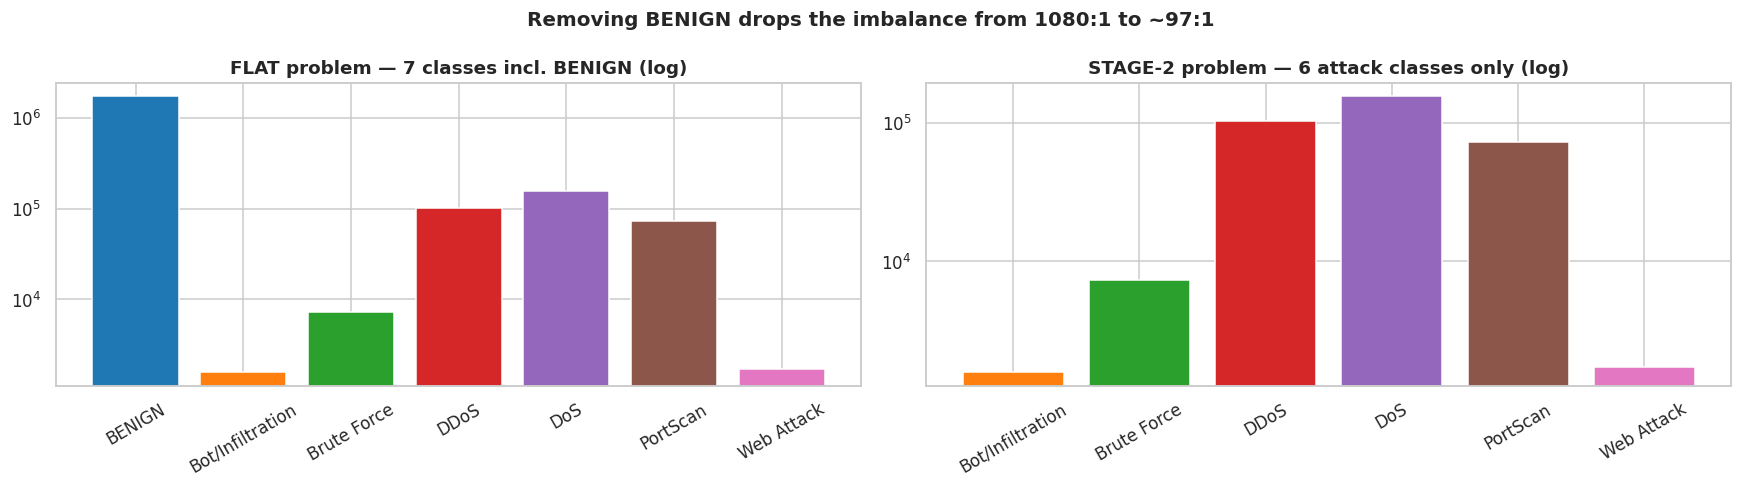

In [2]:
train_path = os.path.join(IN_DIR, 'train_selected.parquet')
test_path  = os.path.join(IN_DIR, 'test_selected.parquet')
feat_path  = os.path.join(IN_DIR, 'selected_features.json')
for p in [train_path, test_path, feat_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'{p} not found. Set IN_DIR to your FeatureSelection mount path.')

with open(feat_path) as f:
    selected_features = json.load(f)['selected_features']

train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)
n_features = len(selected_features)

# ── full matrices ──
X_train = train_df[selected_features].values.astype(np.float32)
X_test  = test_df[selected_features].values.astype(np.float32)
y_train_bin   = train_df['label_binary'].values.astype(np.int64)   # 0 BENIGN / 1 ATTACK
y_test_bin    = test_df['label_binary'].values.astype(np.int64)
y_train_multi = train_df['label_multi'].values.astype(np.int64)    # 0..6
y_test_multi  = test_df['label_multi'].values.astype(np.int64)

# ── attack-only training subset, labels re-indexed 0..5 ──
# map original attack id -> 0-based specialist id
orig_to_spec = {orig: i for i, orig in enumerate(ATTACK_CLASS_IDS)}
spec_to_orig = {i: orig for orig, i in orig_to_spec.items()}

atk_mask_tr   = y_train_multi != BENIGN_IDX
X_atk_train   = X_train[atk_mask_tr]
y_atk_train   = np.array([orig_to_spec[c] for c in y_train_multi[atk_mask_tr]], dtype=np.int64)

_log('')
_log('── SECTION 2 : DATA LOADED ────────────────────────────────')
_log(f'  Features                 : {n_features}')
_log(f'  Full train rows          : {X_train.shape[0]:,}')
_log(f'  Attack-only train rows   : {X_atk_train.shape[0]:,}')
_log(f'  Test rows (real dist.)   : {X_test.shape[0]:,}')
_log('')
_log('  Stage-2 (attack-only) class distribution + imbalance:')
atk_counts = pd.Series(y_atk_train).value_counts().sort_index()
for i in range(N_ATTACK):
    _log(f'    {i} = {ATTACK_CLASS_NAMES[i]:<18} {atk_counts.get(i,0):>8,}')
imb_flat = pd.Series(y_train_multi).value_counts().max() / pd.Series(y_train_multi).value_counts().min()
imb_atk  = atk_counts.max() / atk_counts.min()
_log('')
_log(f'  Imbalance ratio — FLAT (incl. BENIGN) : {imb_flat:>7.1f}:1')
_log(f'  Imbalance ratio — ATTACK-ONLY         : {imb_atk:>7.1f}:1   <-- much milder')

# tuning splits
Xb_tr, Xb_val, yb_tr, yb_val = train_test_split(
    X_train, y_train_bin, test_size=0.2, random_state=RANDOM_SEED, stratify=y_train_bin)
Xa_tr, Xa_val, ya_tr, ya_val = train_test_split(
    X_atk_train, y_atk_train, test_size=0.2, random_state=RANDOM_SEED, stratify=y_atk_train)

# plot the imbalance contrast
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
full_counts = pd.Series(y_train_multi).value_counts().sort_index()
axes[0].bar([CLASS_NAMES[i] for i in full_counts.index], full_counts.values,
            color=sns.color_palette('tab10', 7))
axes[0].set_yscale('log'); axes[0].set_title('FLAT problem — 7 classes incl. BENIGN (log)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[1].bar(ATTACK_CLASS_NAMES, atk_counts.values, color=sns.color_palette('tab10', 7)[1:])
axes[1].set_yscale('log'); axes[1].set_title('STAGE-2 problem — 6 attack classes only (log)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('Removing BENIGN drops the imbalance from 1080:1 to ~97:1', fontsize=13, fontweight='bold')
plt.tight_layout(); _savefig('01_imbalance_contrast.png', fig); plt.show()

## 3. From-Scratch Model Classes (reused)
The same NumPy MLP implementations from notebooks 07 / 08 — binary (sigmoid) for the gate,
multi-class (softmax) for the specialist. Reproduced here so the notebook is self-contained.

In [3]:
class _MLPBase:
    @staticmethod
    def _relu(z): return np.maximum(0.0, z)
    def _init(self, dims, seed):
        rng = np.random.RandomState(seed); self.params = {}
        for i in range(len(dims) - 1):
            self.params[f'W{i+1}'] = rng.randn(dims[i], dims[i+1]).astype(np.float32) * np.sqrt(2.0/dims[i])
            self.params[f'b{i+1}'] = np.zeros(dims[i+1], dtype=np.float32)
    def n_params(self): return sum(v.size for v in self.params.values())

class MLPBinary(_MLPBase):
    """2-hidden-layer binary MLP — ReLU, dropout, sigmoid, weighted BCE+L2, He init, mini-batch GD."""
    def __init__(self, input_dim, hidden=(256,128), lr=0.05, lambda_=0.0, dropout=0.0,
                 batch_size=4096, epochs=50, class_weight=True, random_state=42, verbose=False):
        self.dims=(input_dim,*hidden,1); self.lr=lr; self.lambda_=lambda_; self.dropout=dropout
        self.batch_size=batch_size; self.epochs=epochs; self.class_weight=class_weight
        self.random_state=random_state; self.verbose=verbose; self.history={'train_loss':[],'val_loss':[]}
    @staticmethod
    def _sig(z):
        out=np.empty_like(z); p=z>=0
        out[p]=1/(1+np.exp(-z[p])); e=np.exp(z[~p]); out[~p]=e/(1+e); return out
    def _fwd(self, X, train, rng=None):
        p=self.params; a=X; caches=[]
        n_layers=len(self.dims)-1
        for i in range(1, n_layers):
            z=a@p[f'W{i}']+p[f'b{i}']; h=self._relu(z); mask=None
            if train and self.dropout>0:
                mask=(rng.rand(*h.shape)>=self.dropout).astype(np.float32)/(1-self.dropout); h*=mask
            caches.append((a,z,mask)); a=h
        zL=a@p[f'W{n_layers}']+p[f'b{n_layers}']; yhat=self._sig(zL).ravel()
        caches.append((a,zL,None)); return yhat, caches
    def _loss(self,X,y,sw):
        yhat,_=self._fwd(X,False); e=1e-12
        bce=-(sw*(y*np.log(yhat+e)+(1-y)*np.log(1-yhat+e))).mean()
        l2=(self.lambda_/(2*len(y)))*sum(np.sum(self.params[f'W{i+1}']**2) for i in range(len(self.dims)-1))
        return float(bce+l2)
    def fit(self,X,y,Xv=None,yv=None):
        rng=np.random.RandomState(self.random_state); self._init(self.dims,self.random_state); n=len(y)
        if self.class_weight:
            npos,nneg=(y==1).sum(),(y==0).sum()
            sw=np.where(y==1,n/(2*max(npos,1)),n/(2*max(nneg,1))).astype(np.float32)
        else: sw=np.ones(n,dtype=np.float32)
        swv=np.ones(len(yv),dtype=np.float32) if yv is not None else None
        nL=len(self.dims)-1
        for ep in range(self.epochs):
            idx=rng.permutation(n)
            for s in range(0,n,self.batch_size):
                bi=idx[s:s+self.batch_size]; Xb,yb,swb=X[bi],y[bi],sw[bi]; m=len(bi)
                yhat,caches=self._fwd(Xb,True,rng)
                d=((yhat-yb)*swb).reshape(-1,1)
                for i in range(nL,0,-1):
                    a_prev,z,mask=caches[i-1]
                    gW=(a_prev.T@d)/m+(self.lambda_/m)*self.params[f'W{i}']; gb=d.sum(axis=0)/m
                    if i>1:
                        d=d@self.params[f'W{i}'].T
                        if mask is not None: pass
                        a_prev2,z_prev,mask_prev=caches[i-2]
                        if mask_prev is not None: d*=mask_prev
                        d*=(z_prev>0)
                    self.params[f'W{i}']-=self.lr*gW; self.params[f'b{i}']-=self.lr*gb
            self.history['train_loss'].append(self._loss(X,y,sw))
            if Xv is not None: self.history['val_loss'].append(self._loss(Xv,yv,swv))
            if self.verbose: print(f'  ep {ep+1}/{self.epochs} loss={self.history["train_loss"][-1]:.4f}')
        return self
    def predict_proba(self,X): return self._fwd(X,False)[0]
    def predict(self,X,t=0.5): return (self.predict_proba(X)>=t).astype(int)

class MLPMulti(_MLPBase):
    """2-hidden-layer multi-class MLP — ReLU, softmax, weighted categorical CE+L2, He init."""
    def __init__(self, input_dim, n_classes, hidden=(128,64), lr=0.05, lambda_=0.0, dropout=0.0,
                 batch_size=4096, epochs=40, class_weight=True, random_state=42, verbose=False):
        self.K=n_classes; self.dims=(input_dim,*hidden,n_classes); self.lr=lr; self.lambda_=lambda_
        self.dropout=dropout; self.batch_size=batch_size; self.epochs=epochs; self.class_weight=class_weight
        self.random_state=random_state; self.verbose=verbose; self.history={'train_loss':[],'val_loss':[]}
    @staticmethod
    def _softmax(z):
        z=z-z.max(axis=1,keepdims=True); e=np.exp(z); return e/e.sum(axis=1,keepdims=True)
    def _fwd(self,X,train,rng=None):
        p=self.params; a=X; caches=[]; nL=len(self.dims)-1
        for i in range(1,nL):
            z=a@p[f'W{i}']+p[f'b{i}']; h=self._relu(z); mask=None
            if train and self.dropout>0:
                mask=(rng.rand(*h.shape)>=self.dropout).astype(np.float32)/(1-self.dropout); h*=mask
            caches.append((a,z,mask)); a=h
        zL=a@p[f'W{nL}']+p[f'b{nL}']; P=self._softmax(zL); caches.append((a,zL,None)); return P,caches
    def _loss(self,X,y,sw):
        P,_=self._fwd(X,False); e=1e-12
        ce=-(sw*np.log(P[np.arange(len(y)),y]+e)).mean()
        l2=(self.lambda_/(2*len(y)))*sum(np.sum(self.params[f'W{i+1}']**2) for i in range(len(self.dims)-1))
        return float(ce+l2)
    def fit(self,X,y,Xv=None,yv=None):
        rng=np.random.RandomState(self.random_state); self._init(self.dims,self.random_state); n=len(y)
        if self.class_weight:
            cc=np.bincount(y,minlength=self.K).astype(np.float32); cw=n/(self.K*np.maximum(cc,1)); sw=cw[y]
        else: sw=np.ones(n,dtype=np.float32)
        swv=np.ones(len(yv),dtype=np.float32) if yv is not None else None; nL=len(self.dims)-1
        for ep in range(self.epochs):
            idx=rng.permutation(n)
            for s in range(0,n,self.batch_size):
                bi=idx[s:s+self.batch_size]; Xb,yb,swb=X[bi],y[bi],sw[bi]; m=len(bi)
                P,caches=self._fwd(Xb,True,rng)
                Yoh=np.zeros_like(P); Yoh[np.arange(m),yb]=1.0
                d=(P-Yoh)*swb[:,None]
                for i in range(nL,0,-1):
                    a_prev,z,mask=caches[i-1]
                    gW=(a_prev.T@d)/m+(self.lambda_/m)*self.params[f'W{i}']; gb=d.sum(axis=0)/m
                    if i>1:
                        d=d@self.params[f'W{i}'].T
                        a_prev2,z_prev,mask_prev=caches[i-2]
                        if mask_prev is not None: d*=mask_prev
                        d*=(z_prev>0)
                    self.params[f'W{i}']-=self.lr*gW; self.params[f'b{i}']-=self.lr*gb
            self.history['train_loss'].append(self._loss(X,y,sw))
            if Xv is not None: self.history['val_loss'].append(self._loss(Xv,yv,swv))
            if self.verbose: print(f'  ep {ep+1}/{self.epochs} loss={self.history["train_loss"][-1]:.4f}')
        return self
    def predict_proba(self,X): return self._fwd(X,False)[0]
    def predict(self,X): return np.argmax(self.predict_proba(X),axis=1)

print('MLPBinary + MLPMulti defined (generalised n-layer backprop).')

MLPBinary + MLPMulti defined (generalised n-layer backprop).


In [4]:
# sanity check the reused classes learn (quick 8-epoch fits on small samples)
_si = np.random.RandomState(0).choice(len(Xb_tr), 100000, replace=False)
_b = MLPBinary(n_features, hidden=(64,32), epochs=8, batch_size=8192).fit(Xb_tr[_si], yb_tr[_si], Xb_val, yb_val)
_m = MLPMulti(n_features, N_ATTACK, hidden=(64,32), epochs=8, batch_size=4096).fit(Xa_tr, ya_tr, Xa_val, ya_val)
_log('')
_log('── SECTION 3 : SCRATCH-MODEL SANITY CHECK ─────────────────')
_log(f'  Binary gate quick-fit val F1        : {f1_score(yb_val, _b.predict(Xb_val)):.4f}')
_log(f'  Attack specialist quick-fit macro-F1: {f1_score(ya_val, _m.predict(Xa_val), average="macro"):.4f}')
_log('  (both should be well above chance — confirms backprop is correct)')


── SECTION 3 : SCRATCH-MODEL SANITY CHECK ─────────────────
  Binary gate quick-fit val F1        : 0.8328
  Attack specialist quick-fit macro-F1: 0.9459
  (both should be well above chance — confirms backprop is correct)


## 4. Stage 1 — The Gatekeeper (BENIGN vs ATTACK)
A from-scratch binary MLP using the best config found in notebook 07: `hidden=(256,128),
lr=0.05, dropout=0.0`, class-weighted (the binary task's chosen imbalance strategy). Trained
on the full training set, evaluated on the full test set.


── SECTION 4 : STAGE 1 — GATEKEEPER ───────────────────────
  Trained in 1259.2s  (45,313 params)
  Gate test  accuracy=0.9965  precision=0.9823  recall=0.9966  F1=0.9894
  >> 99.66% of true attacks pass the gate into Stage 2.
  >> 0.34% of attacks are wrongly dropped as BENIGN (unrecoverable).


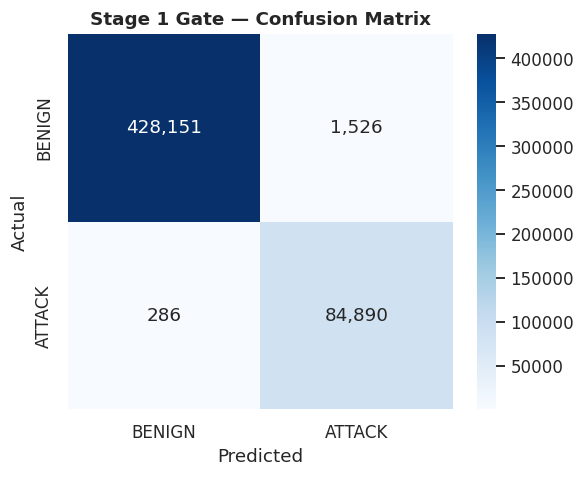

In [5]:
_log('')
_log('── SECTION 4 : STAGE 1 — GATEKEEPER ───────────────────────')
t0 = time.time()
gate = MLPBinary(n_features, hidden=(256,128), lr=0.05, lambda_=0.0, dropout=0.0,
                 batch_size=4096, epochs=50, class_weight=True, random_state=RANDOM_SEED)
gate.fit(X_train, y_train_bin, X_test, y_test_bin)
_log(f'  Trained in {time.time()-t0:.1f}s  ({gate.n_params():,} params)')

gate_pred = gate.predict(X_test)
gate_acc  = accuracy_score(y_test_bin, gate_pred)
gate_prec = precision_score(y_test_bin, gate_pred)
gate_rec  = recall_score(y_test_bin, gate_pred)      # recall on ATTACK = fraction of attacks that pass the gate
gate_f1   = f1_score(y_test_bin, gate_pred)
_log(f'  Gate test  accuracy={gate_acc:.4f}  precision={gate_prec:.4f}  '
     f'recall={gate_rec:.4f}  F1={gate_f1:.4f}')
_log(f'  >> {gate_rec*100:.2f}% of true attacks pass the gate into Stage 2.')
_log(f'  >> {(1-gate_rec)*100:.2f}% of attacks are wrongly dropped as BENIGN (unrecoverable).')

cm = confusion_matrix(y_test_bin, gate_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
            xticklabels=['BENIGN','ATTACK'], yticklabels=['BENIGN','ATTACK'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Stage 1 Gate — Confusion Matrix', fontweight='bold')
plt.tight_layout(); _savefig('02_stage1_gate.png', fig); plt.show()

## 5. Stage 2 — Attack Specialists (6 classes, attack rows only)
Two specialists, both trained on the **attack-only** training set with re-indexed labels 0–5:

- **2a) From-scratch MLP** — class-weighted, `hidden=(128,64), lr=0.05` (notebook-08 config).
- **2b) XGBoost (GPU)** — `max_depth=10, lr=0.3`, inverse-frequency sample weights.

These are evaluated here **in isolation** (perfect-gate assumption — i.e. on the true attack
rows of the test set). Section 6 then measures them inside the real cascade.

In [6]:
# true attack rows in the test set (for isolated Stage-2 evaluation)
atk_mask_te = y_test_multi != BENIGN_IDX
X_atk_test  = X_test[atk_mask_te]
y_atk_test  = np.array([orig_to_spec[c] for c in y_test_multi[atk_mask_te]], dtype=np.int64)

def eval_spec(pred, y):
    return {'accuracy': accuracy_score(y, pred),
            'macro_f1': f1_score(y, pred, average='macro'),
            'weighted_f1': f1_score(y, pred, average='weighted')}

# ── 2a) scratch MLP specialist ──
_log('')
_log('── SECTION 5 : STAGE 2 SPECIALISTS (isolated, perfect-gate) ')
t0 = time.time()
spec_mlp = MLPMulti(n_features, N_ATTACK, hidden=(128,64), lr=0.05, lambda_=0.0, dropout=0.0,
                    batch_size=4096, epochs=40, class_weight=True, random_state=RANDOM_SEED)
spec_mlp.fit(X_atk_train, y_atk_train, X_atk_test, y_atk_test)
mlp_spec_pred = spec_mlp.predict(X_atk_test)
mlp_spec_metrics = eval_spec(mlp_spec_pred, y_atk_test)
_log(f'  [2a] scratch MLP specialist  ({time.time()-t0:.1f}s)')
_log(f'       isolated macro-F1={mlp_spec_metrics["macro_f1"]:.4f}  acc={mlp_spec_metrics["accuracy"]:.4f}')

# ── 2b) XGBoost specialist ──
t0 = time.time()
sw_atk = (lambda y,K: (len(y)/(K*np.maximum(np.bincount(y,minlength=K),1)))[y])(y_atk_train, N_ATTACK)
spec_xgb = xgb.XGBClassifier(objective='multi:softprob', num_class=N_ATTACK,
                             tree_method='hist', device=('cuda' if GPU_AVAILABLE else 'cpu'),
                             n_estimators=400, max_depth=10, learning_rate=0.3,
                             random_state=RANDOM_SEED, verbosity=0)
spec_xgb.fit(X_atk_train, y_atk_train, sample_weight=sw_atk)
xgb_spec_pred = spec_xgb.predict(X_atk_test)
xgb_spec_metrics = eval_spec(xgb_spec_pred, y_atk_test)
_log(f'  [2b] XGBoost specialist  ({time.time()-t0:.1f}s)')
_log(f'       isolated macro-F1={xgb_spec_metrics["macro_f1"]:.4f}  acc={xgb_spec_metrics["accuracy"]:.4f}')

_log('')
_log('  Per-class F1 (isolated, attack-only test rows):')
iso_pc = pd.DataFrame({
    'MLP_specialist': f1_score(y_atk_test, mlp_spec_pred, average=None),
    'XGB_specialist': f1_score(y_atk_test, xgb_spec_pred, average=None),
}, index=ATTACK_CLASS_NAMES)
_log(iso_pc.to_string())
display(iso_pc)


── SECTION 5 : STAGE 2 SPECIALISTS (isolated, perfect-gate) 
  [2a] scratch MLP specialist  (86.1s)
       isolated macro-F1=0.9750  acc=0.9975
  [2b] XGBoost specialist  (8.4s)
       isolated macro-F1=0.9975  acc=0.9997

  Per-class F1 (isolated, attack-only test rows):
                  MLP_specialist  XGB_specialist
Bot/Infiltration          0.9682          1.0000
Brute Force               0.9736          1.0000
DDoS                      0.9991          1.0000
DoS                       0.9983          0.9997
PortScan                  0.9989          0.9996
Web Attack                0.9120          0.9860


,MLP_specialist,XGB_specialist
Bot/Infiltration,0.9682,1.0000
Brute Force,0.9736,1.0000
DDoS,0.9991,1.0000
DoS,0.9983,0.9997
PortScan,0.9989,0.9996
Web Attack,0.9120,0.9860


## 6. End-to-End Cascade Evaluation (the honest test)
Now the real thing. Every test flow goes: **Stage 1 gate → if predicted ATTACK, Stage 2
specialist**. Rows the gate calls BENIGN are output as BENIGN (final class 0); rows it calls
ATTACK get their 6-class specialist prediction mapped back to the original 7-class index.

This folds in error propagation — attacks the gate misses are counted as BENIGN errors, exactly
as they would be in deployment. We build a full 7-class prediction vector and score it against
`label_multi`, so it is directly comparable to the flat models.


── SECTION 6 : END-TO-END CASCADE (full 7-class, real test) 
  Cascade [gate + MLP specialist]  macro-F1=0.9061  acc=0.9961
  Cascade [gate + XGB specialist]  macro-F1=0.9280  acc=0.9964

  Per-class F1 (full 7-class, end-to-end):
                  Cascade_MLP  Cascade_XGB
BENIGN                 0.9979       0.9979
Bot/Infiltration       0.5767       0.5863
Brute Force            0.9653       0.9756
DDoS                   0.9979       0.9986
DoS                    0.9850       0.9862
PortScan               0.9929       0.9933
Web Attack             0.8274       0.9584


,Cascade_MLP,Cascade_XGB
BENIGN,0.9979,0.9979
Bot/Infiltration,0.5767,0.5863
Brute Force,0.9653,0.9756
DDoS,0.9979,0.9986
DoS,0.9850,0.9862
PortScan,0.9929,0.9933
Web Attack,0.8274,0.9584


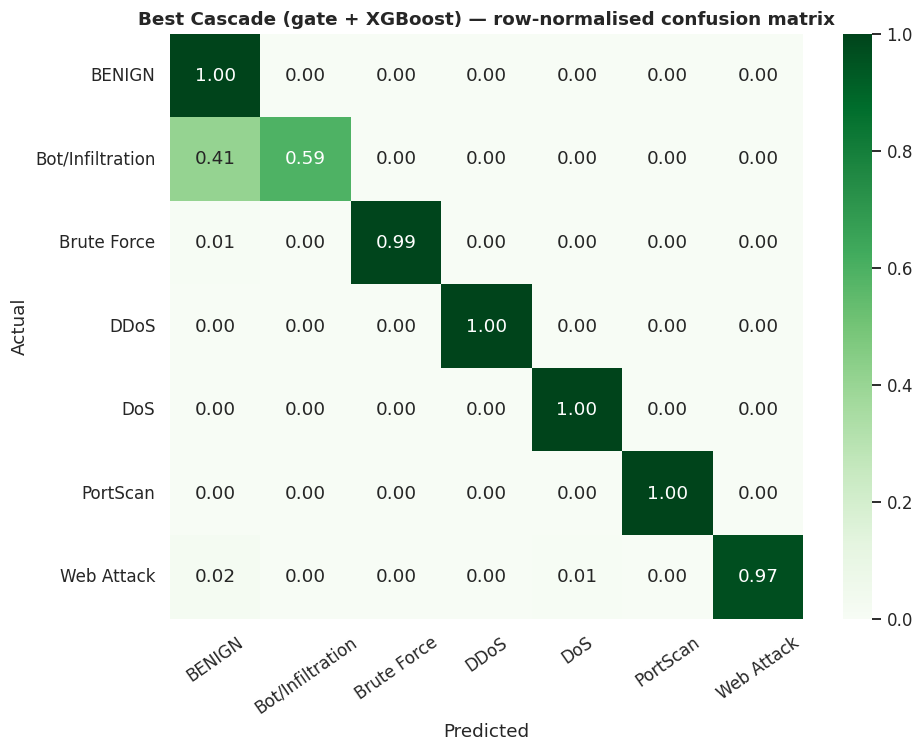

In [7]:
def run_cascade(specialist):
    """Full pipeline: gate decides BENIGN/ATTACK; specialist labels the predicted-attack rows."""
    final = np.zeros(len(X_test), dtype=np.int64)        # default everyone to BENIGN (idx 0)
    pred_attack = gate_pred == 1                          # gate's ATTACK calls
    if pred_attack.sum() > 0:
        spec_pred = specialist.predict(X_test[pred_attack])      # 0..5
        final[pred_attack] = np.array([spec_to_orig[s] for s in spec_pred])  # back to 1..6
    return final

def eval_full(pred):
    return {'accuracy': accuracy_score(y_test_multi, pred),
            'macro_f1': f1_score(y_test_multi, pred, average='macro'),
            'weighted_f1': f1_score(y_test_multi, pred, average='weighted'),
            'macro_prec': precision_score(y_test_multi, pred, average='macro'),
            'macro_rec': recall_score(y_test_multi, pred, average='macro')}

casc_mlp_pred = run_cascade(spec_mlp)
casc_xgb_pred = run_cascade(spec_xgb)
casc_mlp = eval_full(casc_mlp_pred)
casc_xgb = eval_full(casc_xgb_pred)

_log('')
_log('── SECTION 6 : END-TO-END CASCADE (full 7-class, real test) ')
_log(f'  Cascade [gate + MLP specialist]  macro-F1={casc_mlp["macro_f1"]:.4f}  acc={casc_mlp["accuracy"]:.4f}')
_log(f'  Cascade [gate + XGB specialist]  macro-F1={casc_xgb["macro_f1"]:.4f}  acc={casc_xgb["accuracy"]:.4f}')

# per-class F1 of both cascades
casc_pc = pd.DataFrame({
    'Cascade_MLP': f1_score(y_test_multi, casc_mlp_pred, average=None),
    'Cascade_XGB': f1_score(y_test_multi, casc_xgb_pred, average=None),
}, index=CLASS_NAMES)
_log('')
_log('  Per-class F1 (full 7-class, end-to-end):')
_log(casc_pc.to_string())
display(casc_pc)

# confusion matrix of the better cascade
best_casc_pred = casc_xgb_pred if casc_xgb['macro_f1'] >= casc_mlp['macro_f1'] else casc_mlp_pred
best_casc_name = 'gate + XGBoost' if casc_xgb['macro_f1'] >= casc_mlp['macro_f1'] else 'gate + MLP'
cm = confusion_matrix(y_test_multi, best_casc_pred)
cm_norm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Best Cascade ({best_casc_name}) — row-normalised confusion matrix', fontweight='bold')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout(); _savefig('03_cascade_confusion.png', fig); plt.show()

## 7. Cascade vs Flat — Does the Two-Stage Design Help?
The decisive comparison. Flat-model numbers are reproduced from notebooks 08 (scratch MLP)
and 09 (XGBoost). For a fair architecture-matched comparison: **Cascade-MLP vs Flat-MLP**
and **Cascade-XGB vs Flat-XGB**.


── SECTION 7 : CASCADE vs FLAT ────────────────────────────
  Overall (full 7-class test set):
             Flat MLP  Cascade MLP  Flat XGB  Cascade XGB
accuracy       0.9924       0.9961    0.9990       0.9964
macro_f1       0.8439       0.9061    0.9722       0.9280
weighted_f1    0.9944       0.9962    0.9991       0.9965
macro_prec     0.8070       0.8858    0.9608       0.9211
macro_rec      0.9878       0.9320    0.9863       0.9352


,Flat MLP,Cascade MLP,Flat XGB,Cascade XGB
accuracy,0.9924,0.9961,0.9990,0.9964
macro_f1,0.8439,0.9061,0.9722,0.9280
weighted_f1,0.9944,0.9962,0.9991,0.9965
macro_prec,0.8070,0.8858,0.9608,0.9211
macro_rec,0.9878,0.9320,0.9863,0.9352



  MLP : flat macro-F1=0.8439  ->  cascade=0.9061  (delta +0.0622)
  XGB : flat macro-F1=0.9722  ->  cascade=0.9280  (delta -0.0442)

  Per-class F1 — flat vs cascade:
                  Flat MLP  Cascade MLP  Flat XGB  Cascade XGB
BENIGN              0.9955       0.9979    0.9994       0.9979
Bot/Infiltration    0.2291       0.5767    0.8279       0.5863
Brute Force         0.9685       0.9653    1.0000       0.9756
DDoS                0.9987       0.9979    0.9998       0.9986
DoS                 0.9914       0.9850    0.9985       0.9862
PortScan            0.9934       0.9929    0.9939       0.9933
Web Attack          0.7306       0.8274    0.9859       0.9584


,Flat MLP,Cascade MLP,Flat XGB,Cascade XGB
BENIGN,0.9955,0.9979,0.9994,0.9979
Bot/Infiltration,0.2291,0.5767,0.8279,0.5863
Brute Force,0.9685,0.9653,1.0000,0.9756
DDoS,0.9987,0.9979,0.9998,0.9986
DoS,0.9914,0.9850,0.9985,0.9862
PortScan,0.9934,0.9929,0.9939,0.9933
Web Attack,0.7306,0.8274,0.9859,0.9584


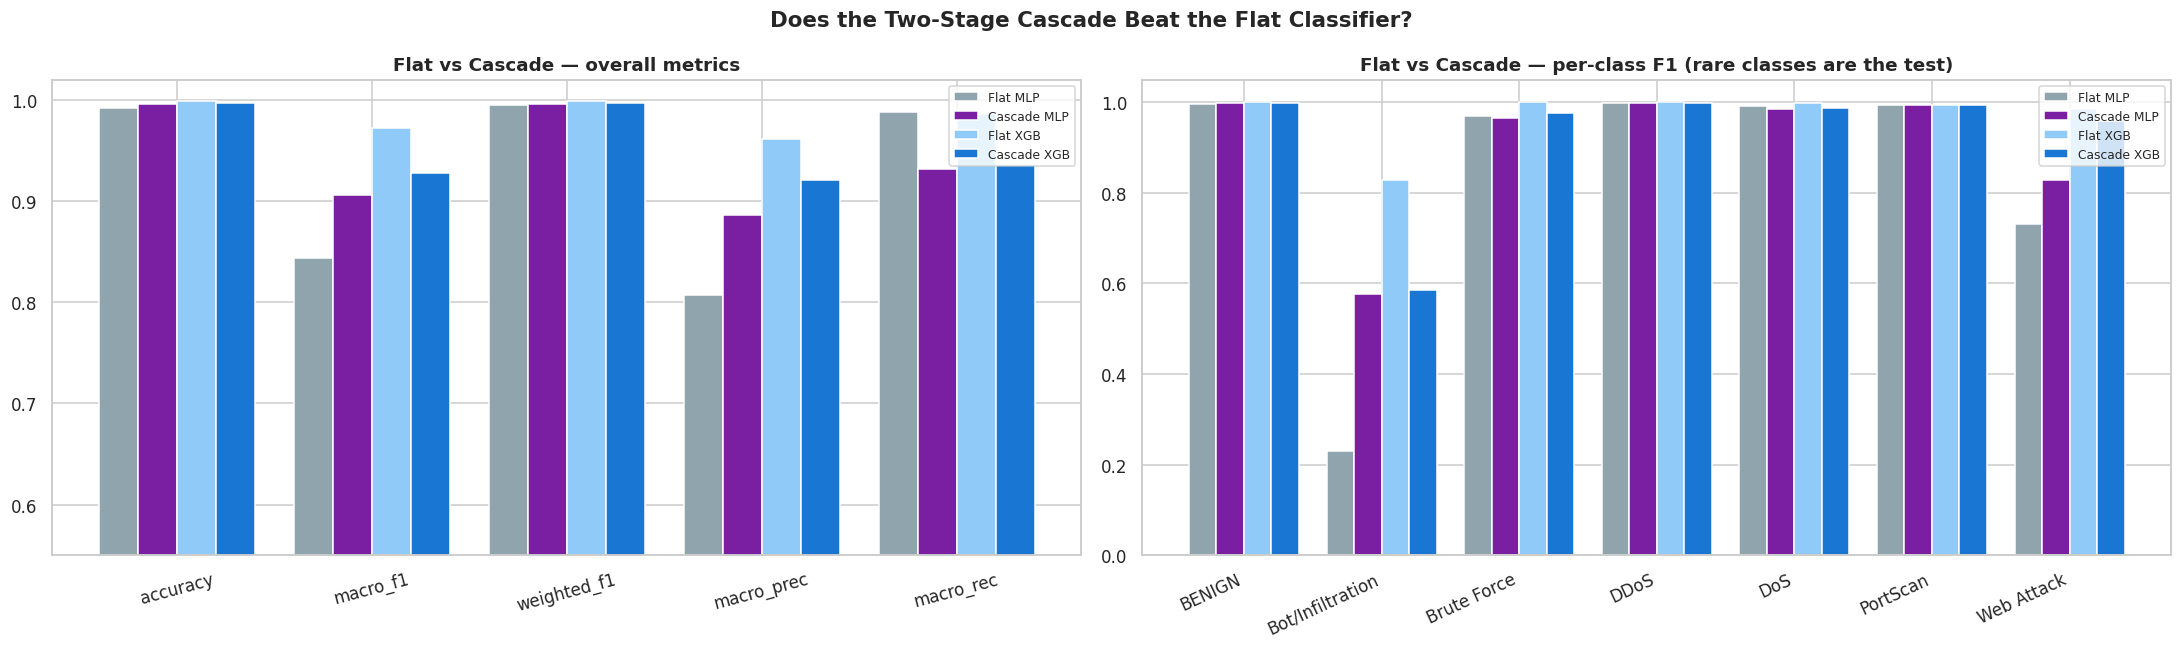

In [8]:
# flat multi-class results from earlier notebooks
flat = {
    'Flat MLP':  {'accuracy':0.9924,'macro_f1':0.8439,'weighted_f1':0.9944,'macro_prec':0.8070,'macro_rec':0.9878},
    'Flat XGB':  {'accuracy':0.9990,'macro_f1':0.9722,'weighted_f1':0.9991,'macro_prec':0.9608,'macro_rec':0.9863},
}
flat_pc = {
    'Flat MLP': [0.9955,0.2291,0.9685,0.9987,0.9914,0.9934,0.7306],
    'Flat XGB': [0.9994,0.8279,1.0000,0.9998,0.9985,0.9939,0.9859],
}

overall = pd.DataFrame({
    'Flat MLP':    flat['Flat MLP'],
    'Cascade MLP': casc_mlp,
    'Flat XGB':    flat['Flat XGB'],
    'Cascade XGB': casc_xgb,
})
_log('')
_log('── SECTION 7 : CASCADE vs FLAT ────────────────────────────')
_log('  Overall (full 7-class test set):')
_log(overall.to_string())
display(overall)

_log('')
_log(f'  MLP : flat macro-F1={flat["Flat MLP"]["macro_f1"]:.4f}  ->  '
     f'cascade={casc_mlp["macro_f1"]:.4f}  (delta {casc_mlp["macro_f1"]-flat["Flat MLP"]["macro_f1"]:+.4f})')
_log(f'  XGB : flat macro-F1={flat["Flat XGB"]["macro_f1"]:.4f}  ->  '
     f'cascade={casc_xgb["macro_f1"]:.4f}  (delta {casc_xgb["macro_f1"]-flat["Flat XGB"]["macro_f1"]:+.4f})')

# per-class comparison table
pc_compare = pd.DataFrame({
    'Flat MLP':    flat_pc['Flat MLP'],
    'Cascade MLP': f1_score(y_test_multi, casc_mlp_pred, average=None),
    'Flat XGB':    flat_pc['Flat XGB'],
    'Cascade XGB': f1_score(y_test_multi, casc_xgb_pred, average=None),
}, index=CLASS_NAMES)
_log('')
_log('  Per-class F1 — flat vs cascade:')
_log(pc_compare.to_string())
display(pc_compare)

# visuals
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
ax = axes[0]
mets = ['accuracy','macro_f1','weighted_f1','macro_prec','macro_rec']
xx = np.arange(len(mets)); cols = ['#90A4AE','#7B1FA2','#90CAF9','#1976D2']
for i, mdl in enumerate(['Flat MLP','Cascade MLP','Flat XGB','Cascade XGB']):
    ax.bar(xx+(i-1.5)*0.2, [overall.loc[m,mdl] for m in mets], 0.2, label=mdl, color=cols[i])
ax.set_xticks(xx); ax.set_xticklabels(mets, rotation=15); ax.set_ylim(0.55,1.02)
ax.set_title('Flat vs Cascade — overall metrics', fontweight='bold'); ax.legend(fontsize=8)

ax = axes[1]
xx = np.arange(7)
for i, mdl in enumerate(['Flat MLP','Cascade MLP','Flat XGB','Cascade XGB']):
    ax.bar(xx+(i-1.5)*0.2, pc_compare[mdl].values, 0.2, label=mdl, color=cols[i])
ax.set_xticks(xx); ax.set_xticklabels(CLASS_NAMES, rotation=25, ha='right'); ax.set_ylim(0,1.05)
ax.set_title('Flat vs Cascade — per-class F1 (rare classes are the test)', fontweight='bold')
ax.legend(fontsize=8)
plt.suptitle('Does the Two-Stage Cascade Beat the Flat Classifier?', fontsize=14, fontweight='bold')
plt.tight_layout(); _savefig('04_cascade_vs_flat.png', fig); plt.show()

## 8. Save & Summary

In [9]:
import joblib
np.savez(os.path.join(OUT_DIR,'cascade_gate_mlp.npz'), **gate.params)
np.savez(os.path.join(OUT_DIR,'cascade_specialist_mlp.npz'), **spec_mlp.params)
spec_xgb.save_model(os.path.join(OUT_DIR,'cascade_specialist_xgb.json'))
overall.to_csv(os.path.join(OUT_DIR,'cascade_vs_flat_overall.csv'))
pc_compare.to_csv(os.path.join(OUT_DIR,'cascade_vs_flat_perclass.csv'))
with open(os.path.join(OUT_DIR,'cascade_metrics.json'),'w') as f:
    json.dump({
        'gate': {'accuracy':gate_acc,'precision':gate_prec,'recall_attack':gate_rec,'f1':gate_f1},
        'specialist_isolated': {'mlp':mlp_spec_metrics,'xgb':xgb_spec_metrics},
        'cascade_end_to_end': {'mlp':casc_mlp,'xgb':casc_xgb},
        'flat_reference': flat,
    }, f, indent=2)

_log('')
_log('── SECTION 8 : FILES SAVED ────────────────────────────────')
for fn in ['cascade_gate_mlp.npz','cascade_specialist_mlp.npz','cascade_specialist_xgb.json',
           'cascade_vs_flat_overall.csv','cascade_vs_flat_perclass.csv','cascade_metrics.json']:
    print('  '+fn); _log('  '+fn)


── SECTION 8 : FILES SAVED ────────────────────────────────
  cascade_gate_mlp.npz
  cascade_gate_mlp.npz
  cascade_specialist_mlp.npz
  cascade_specialist_mlp.npz
  cascade_specialist_xgb.json
  cascade_specialist_xgb.json
  cascade_vs_flat_overall.csv
  cascade_vs_flat_overall.csv
  cascade_vs_flat_perclass.csv
  cascade_vs_flat_perclass.csv
  cascade_metrics.json
  cascade_metrics.json


In [10]:
_log('')
_log('=' * 70)
_log('SUMMARY  --  HIERARCHICAL (TWO-STAGE) CLASSIFIER')
_log('=' * 70)
_log('')
_log(f'  Stage 1 gate (BENIGN vs ATTACK):')
_log(f'    F1={gate_f1:.4f}  recall(ATTACK)={gate_rec:.4f}  '
     f'-> {(1-gate_rec)*100:.2f}% of attacks lost at the gate')
_log('')
_log(f'  Stage 2 specialists (isolated, perfect-gate macro-F1):')
_log(f'    scratch MLP : {mlp_spec_metrics["macro_f1"]:.4f}')
_log(f'    XGBoost     : {xgb_spec_metrics["macro_f1"]:.4f}')
_log('')
_log(f'  END-TO-END cascade vs FLAT (full 7-class macro-F1):')
_log(f'    MLP : flat {flat["Flat MLP"]["macro_f1"]:.4f}  ->  cascade {casc_mlp["macro_f1"]:.4f}  '
     f'({casc_mlp["macro_f1"]-flat["Flat MLP"]["macro_f1"]:+.4f})')
_log(f'    XGB : flat {flat["Flat XGB"]["macro_f1"]:.4f}  ->  cascade {casc_xgb["macro_f1"]:.4f}  '
     f'({casc_xgb["macro_f1"]-flat["Flat XGB"]["macro_f1"]:+.4f})')
_log('')
_log('  Interpretation:')
_log('    - The attack-only specialist faces ~97:1 imbalance vs the flat model\'s 1080:1.')
_log('    - But the cascade inherits Stage-1 gate errors: any attack the gate misses is')
_log('      counted as a BENIGN mistake and never reaches the specialist.')
_log('    - Whether the cascade wins depends on whether the milder Stage-2 imbalance')
_log('      outweighs the gate error rate. See the per-class table for where it helps.')

FIGURE_INDEX = [
    ('01_imbalance_contrast.png','Flat 7-class vs attack-only class distribution'),
    ('02_stage1_gate.png','Stage-1 gate confusion matrix'),
    ('03_cascade_confusion.png','Best cascade 7-class confusion matrix'),
    ('04_cascade_vs_flat.png','Cascade vs flat — overall + per-class'),
]
_log(''); _log('  Figures:')
for fn, d in FIGURE_INDEX: _log(f'    {fn:<30} {d}')
write_report()

print('\n'+'='*55)
print('HIERARCHICAL CLASSIFIER COMPLETE')
print('='*55)
print(f'  Gate recall(ATTACK)        : {gate_rec:.4f}')
print(f'  Cascade-MLP macro-F1       : {casc_mlp["macro_f1"]:.4f}  (flat MLP {flat["Flat MLP"]["macro_f1"]:.4f})')
print(f'  Cascade-XGB macro-F1       : {casc_xgb["macro_f1"]:.4f}  (flat XGB {flat["Flat XGB"]["macro_f1"]:.4f})')
print(f'  Report  -> {OUT_DIR}/Modeling_Hierarchical_Report.txt')
print(f'  Figures -> {FIGURES_DIR}/  ({len(FIGURE_INDEX)} figures)')


SUMMARY  --  HIERARCHICAL (TWO-STAGE) CLASSIFIER

  Stage 1 gate (BENIGN vs ATTACK):
    F1=0.9894  recall(ATTACK)=0.9966  -> 0.34% of attacks lost at the gate

  Stage 2 specialists (isolated, perfect-gate macro-F1):
    scratch MLP : 0.9750
    XGBoost     : 0.9975

  END-TO-END cascade vs FLAT (full 7-class macro-F1):
    MLP : flat 0.8439  ->  cascade 0.9061  (+0.0622)
    XGB : flat 0.9722  ->  cascade 0.9280  (-0.0442)

  Interpretation:
    - The attack-only specialist faces ~97:1 imbalance vs the flat model's 1080:1.
    - But the cascade inherits Stage-1 gate errors: any attack the gate misses is
      counted as a BENIGN mistake and never reaches the specialist.
    - Whether the cascade wins depends on whether the milder Stage-2 imbalance
      outweighs the gate error rate. See the per-class table for where it helps.

  Figures:
    01_imbalance_contrast.png      Flat 7-class vs attack-only class distribution
    02_stage1_gate.png             Stage-1 gate confusion matrix